In [1]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

Here we are considering a linear oscillator under a charge drive.

The Hamiltonian is (e.g., Chao's thesis Eq. 43) 
$$
H =  \Delta a^{\dagger} a + [ \epsilon e^{-i \omega_d t} - \epsilon^* e^{i \omega_d t}] (a^{\dagger}-a)
$$
We'll just define $\varepsilon = \epsilon e^{-i \omega_d t}$
$$
H =  \Delta a^{\dagger} a + (\varepsilon-\varepsilon^*)( a^{\dagger} - a)
$$
$$
H =  \Delta a^{\dagger} a + (\varepsilon_{im})( a^{\dagger} - a)
$$

We don't need any cumulant expansion here, but let's calculate the 2nd order terms for practice. We get the Heisenberg equations of motion

$$
\dot{a}  = - i \Delta a - i (\varepsilon-\varepsilon^*)
$$
$$
\dot{aa}  =  - 2 i \Delta a a - 2 i a (\varepsilon-\varepsilon^*)
$$
$$
\dot{a^{\dagger} a}  = - i (\varepsilon-\varepsilon^*) (a+a^{\dagger})
$$

Here we can take expectation values to get an exact closed system of ODEs.

$$
\dot{\langle a \rangle} =  - i \Delta \langle a \rangle - i (\varepsilon-\varepsilon^*)
$$
$$
\dot{\langle aa \rangle}  =  - 2 i \Delta \langle a a \rangle - 2 i \langle a \rangle (\varepsilon-\varepsilon^*)
$$
$$
\dot{\langle a^{\dagger} a \rangle} =   (\langle a \rangle + \langle a \rangle^{\dagger})(\varepsilon-\varepsilon^*)
$$

In [2]:
disp = -1
phi = 0.0
Delta = 0.4*2*np.pi
epsilon_R = 0.0
epsilon_I = 0.3
omega_d = 0.4*2*np.pi

In [3]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('Delta', Delta, is_excitation=True)
sim.add_param('phi', phi)
sim.add_param('IC', disp)
sim.add_param('epsilon_R', epsilon_R)
sim.add_param('epsilon_I', epsilon_I)
sim.add_param('omega_d', omega_d)

# sim.add_EOM('a', '- 1j*Delta*a - 1j*(varepsilon-conjugate(varepsilon))',IC_str='IC')
# sim.add_EOM('aa', '- 2j*Delta*aa - 2j*(varepsilon-conjugate(varepsilon))*a', IC_str='IC**2')
# sim.add_EOM('na', '- 1j*(varepsilon-conjugate(varepsilon))*(a-conjugate(a))',IC_str='abs(IC)**2')
# sim.add_drive_EOM('varepsilon', '(epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))')

sim.add_EOM('a', '- 1j*Delta*a - 1j*((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))-conjugate((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))))',IC_str='IC')
sim.add_EOM('aa', '- 2j*Delta*aa - 2j*((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))-conjugate((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))))*a', IC_str='IC**2')
sim.add_EOM('na', '- 1j*((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))-conjugate((epsilon_R+1j*epsilon_I)*exp(-1j*(omega_d*t + phi))))*(a+conjugate(a))',IC_str='abs(IC)**2')

sim.set_solve_type('all')

sim.specify_time(t_f=20, pts=1001)

sim.validate(print_result=False)

Recent change to specify_time(), check implementation
Simulation validation success!


In [4]:
x, t = sim.quick_trace()

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


In [5]:
b = x[0,:]+1j*x[1,:]
bb = x[2,:]+1j*x[3,:]
nb = x[4,:]+1j*x[5,:]
# varepsilon = x[6,:]+1j*x[7,:]

In [6]:
def plot_Qfunc(a, aa, na, ax=None, plot_arg=None):

    if ax == None:
        ax = plt.gca()
    
    ad = np.conjugate(a)
    adad = np.conjugate(aa)
    sxx = 1/2 + 1/2*( (aa - a*a) + 2*(na - ad*a) + (adad - ad*ad))
    syy = 1/2 - 1/2*( (aa - a*a) - 2*(na - ad*a) + (adad - ad*ad))
    sxy = np.imag(1/2*((aa - a*a) - (adad - ad*ad)))
    covar =  np.real(np.array([[sxx, sxy], [sxy, syy]]))

    print(covar)
    print(' ')

    phi = np.linspace(0, 2*np.pi, 101)
    
    print(np.argsort(np.linalg.eig(covar)[0]))

    order = np.argsort(np.linalg.eig(covar)[0])
    major_idx = order[1]
    minor_idx = order[0]
    
    theta = -np.angle(np.linalg.eig(covar)[1][:,1][minor_idx]+1j*np.linalg.eig(covar)[1][:,1][major_idx])
    Smajor = np.sort(np.linalg.eig(covar)[0])[major_idx]
    Sminor = np.sort(np.linalg.eig(covar)[0])[minor_idx]
    
    x1 = np.sqrt(Smajor)*np.cos(phi)*2
    y1 = np.sqrt(Sminor)*np.sin(phi)*2
    
    x2 = x1*np.cos(theta) + y1*np.sin(theta) + np.real(a)
    y2 = -x1*np.sin(theta) + y1*np.cos(theta) + np.imag(a)

    if plot_arg == None:
        ax.plot(x2,y2)
    else:
        ax.plot(x2,y2,plot_arg)
    # ax.xlim([-7,7])
    # ax.ylim([-7,7])
    # plt.gca().set_aspect('equal')
    # plt.grid()
    # plt.show()

    

In [7]:
# x, t = sim.solve()

# xd = x.copy()
# td = t.copy()

In [8]:
# from cuda_cqed.cumulant_plot.cumulant_slider_plot import cumulant_slider_plot

# b = x[0, :] + 1j * x[1, :]
# bb = x[2, :] + 1j * x[3, :]
# nb = x[4, :] + 1j * x[5, :]

# axes_dict = {'g2': sim.paramsweep_dict['g2'], 'time ': t[0,:]}

# plt.close('all')
# cumulant_slider_plot(b, bb, nb, axes_dict, plot_range=20)

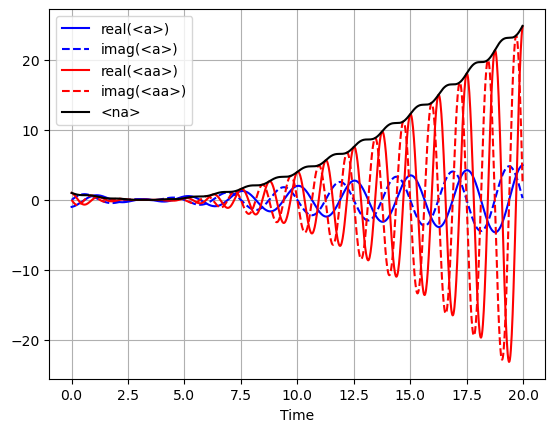

In [17]:
tlist = np.unique(t)
plt.plot(tlist, np.real(b),'b-',label='real(<a>)')
plt.plot(tlist, np.imag(b),'b--',label='imag(<a>)')
plt.plot(tlist, np.real(bb),'r-',label='real(<aa>)')
plt.plot(tlist, np.imag(bb),'r--',label='imag(<aa>)')
# plt.plot(tlist, np.real(varepsilon),'m-',label='real(varepsilon)')
# plt.plot(tlist, np.imag(varepsilon),'m--',label='imag(<varepsilon>)')
plt.plot(tlist, np.real(nb),'k',label='<na>')
plt.legend()
plt.xlabel('Time')
plt.grid()
plt.show()

# QuTiP version

In [10]:
from base64 import b64encode

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib import animation
from qutip import (about, basis, coherent, destroy, displace, expect, mesolve,
                   num, plot_fock_distribution, plot_wigner, squeeze, variance, Options)

%matplotlib inline

In [11]:
N = 30

# operators
a = destroy(N)
n = num(N)
x = (a + a.dag()) / np.sqrt(2)
p = -1j * (a - a.dag()) / np.sqrt(2)

varepsilon = (epsilon_R+1j*epsilon_I)*np.exp(1j*(omega_d*tlist + phi))

H0 = Delta*a.dag()*a

H1 = a.dag()-a

H = [H0, [H1, varepsilon-np.conjugate(varepsilon)]]

c_ops = [0.0*a]

In [12]:
def plot_expect_with_variance(N, op_list, op_title, states):
    """
    Plot the expectation value of an operator (list of operators)
    with an envelope that describes the operators variance.
    """

    fig, axes = plt.subplots(1, len(op_list), figsize=(14, 3))

    for idx, op in enumerate(op_list):

        e_op = expect(op, states)
        v_op = variance(op, states)

        axes[idx].fill_between(
            tlist, e_op - np.sqrt(v_op), e_op + np.sqrt(v_op), color="green",
            alpha=0.5)
        axes[idx].plot(tlist, e_op, label="expectation")
        axes[idx].set_xlabel("Time")
        axes[idx].set_title(op_title[idx])

    return fig, axes

C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\numpy\ma\core.py:2881: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,
C:\Users\boris\anaconda3\envs\fullconda\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


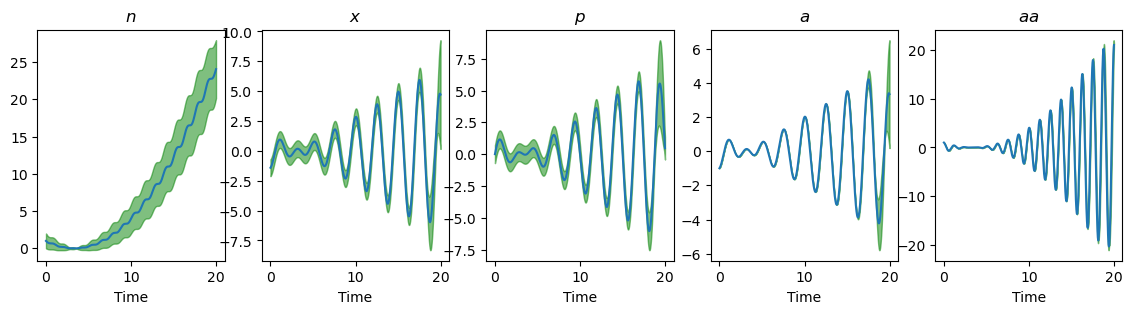

In [13]:
psi0 = coherent(N, disp)

result = mesolve(H, psi0, t, c_ops, [])

plot_expect_with_variance(N, [n, x, p, a, a*a], [r"$n$", r"$x$", r"$p$",  r"$a$",  r"$aa$"],
                          result.states);
plt.show()

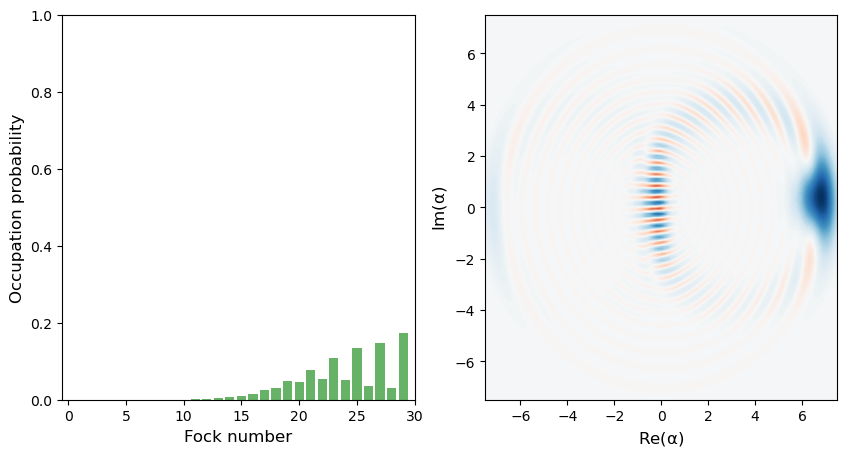

In [14]:
# i = 0

# fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# axes[0].cla()
# plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
# plot_wigner(result.states[i], fig=fig, ax=axes[1])
# plt.show()

i = -1

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].cla()
plot_fock_distribution(result.states[i], fig=fig, ax=axes[0])
plot_wigner(result.states[i], fig=fig, ax=axes[1])
plt.show()

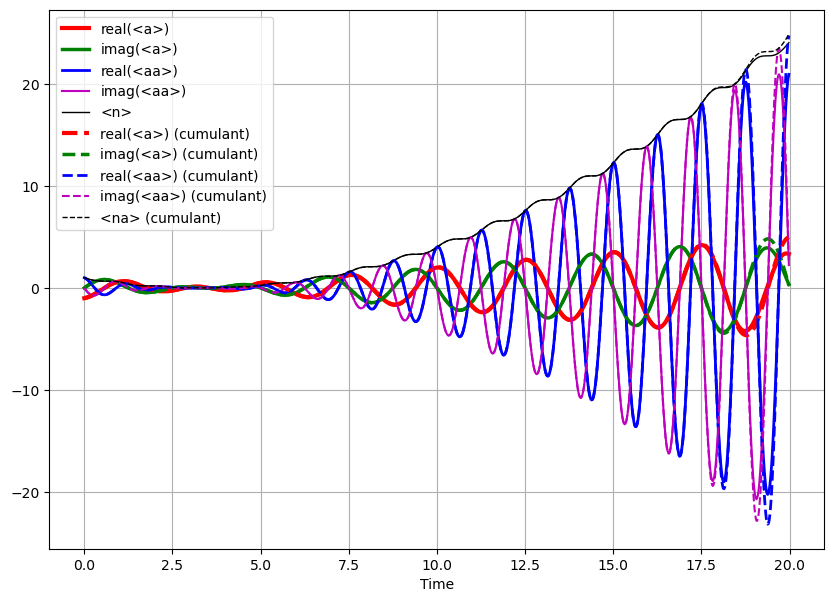

In [15]:
plt.figure(figsize=(10,7))
plt.plot(t,np.real(expect(a, result.states)),'r-',label='real(<a>)',linewidth=3)
plt.plot(t,np.imag(expect(a, result.states)),'g-',label='imag(<a>)',linewidth=2.5)
plt.plot(t,np.real(expect(a*a, result.states)),'b-',label='real(<aa>)',linewidth=2)
plt.plot(t,np.imag(expect(a*a, result.states)),'m-',label='imag(<aa>)',linewidth=1.5)
plt.plot(t,expect(a.dag()*a, result.states),'k-',label='<n>',linewidth=1)

plt.plot(t,np.real(b),'r--',label='real(<a>) (cumulant)',linewidth=3)
plt.plot(t,np.imag(b),'g--',label='imag(<a>) (cumulant)',linewidth=2.5)
plt.plot(t,np.real(bb),'b--',label='real(<aa>) (cumulant)',linewidth=2)
plt.plot(t,np.imag(bb),'m--',label='imag(<aa>) (cumulant)',linewidth=1.5)
plt.plot(t,np.real(nb),'k--',label='<na> (cumulant)',linewidth=1)
# plt.xlim([0,30])
# plt.ylim([-0.1,0.1])
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.show()